          age     fare  sibsp  parch  Cluster
0   22.000000   7.2500      1      0        2
1   38.000000  71.2833      1      0        1
2   26.000000   7.9250      0      0        2
3   35.000000  53.1000      1      0        2
4   35.000000   8.0500      0      0        2
5   29.699118   8.4583      0      0        2
6   54.000000  51.8625      0      0        1
7    2.000000  21.0750      3      1        0
8   27.000000  11.1333      0      2        0
9   14.000000  30.0708      1      0        2
10   4.000000  16.7000      1      1        0
11  58.000000  26.5500      0      0        1
12  20.000000   8.0500      0      0        2
13  39.000000  31.2750      1      5        0
14  14.000000   7.8542      0      0        2
15  55.000000  16.0000      0      0        1
16   2.000000  29.1250      4      1        0
17  29.699118  13.0000      0      0        2
18  31.000000  18.0000      1      0        2
19  29.699118   7.2250      0      0        2

Cluster Counts:
Cluster
2    592


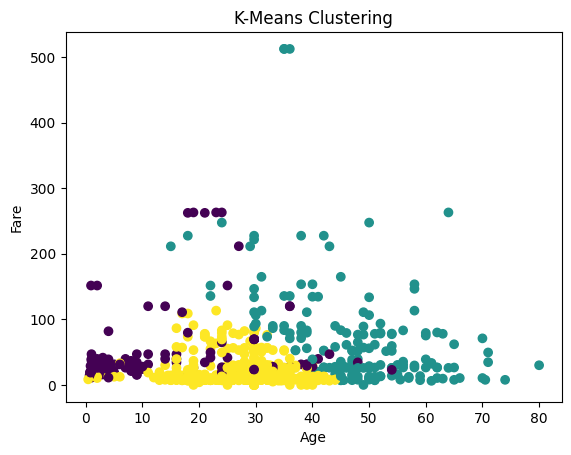

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# Load dataset
df = pd.read_csv("Titanic.csv")


# Handle missing values
df["age"] = df["age"].fillna(df["age"].mean())


# Select numerical features
X = df[["age", "fare", "sibsp", "parch"]]


# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# K-Means
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(X_scaled)


# Add cluster number to dataset
df["Cluster"] = kmeans.labels_


# Display clusters
print(df[["age", "fare", "sibsp", "parch", "Cluster"]].head(20))


# Number of passengers in each cluster
print("\nCluster Counts:")
print(df["Cluster"].value_counts())


# Visualize clusters
plt.scatter(
    df["age"],
    df["fare"],
    c=df["Cluster"]
)

plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("K-Means Clustering")
plt.show()